In [1]:
import pandas as pd
import numpy as np
import pickle
import sys
import os

import matplotlib.pyplot as plt

from prophet import Prophet

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    GRU,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

Importing plotly failed. Interactive plots will not work.


In [2]:
sys.path.append(
    os.path.abspath("..")
)

In [3]:
from utils.sequence_utils import (
    create_residual_sequences
)

In [4]:
train_df = pd.read_parquet(
    "../data/train_df.parquet"
)

val_df = pd.read_parquet(
    "../data/val_df.parquet"
)

with open("../data/scalers.pkl", "rb") as f:
    scalers = pickle.load(f)

/Users/lehaan/Desktop/FYP_Long_Term/tf_metal_env/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [5]:
selected_containers = np.load(
    "../data/selected_containers.npy",
    allow_pickle=True
)
print(selected_containers)

['c_10032' 'c_10034' 'c_10089' 'c_10132' 'c_1016' 'c_10306' 'c_10312'
 'c_10382' 'c_10393' 'c_10641' 'c_10695' 'c_10733' 'c_10878' 'c_10898'
 'c_11013' 'c_11087' 'c_11203' 'c_11307' 'c_11327' 'c_11461' 'c_11735'
 'c_11752' 'c_1181' 'c_1186' 'c_11996' 'c_12060' 'c_12158' 'c_12164'
 'c_12174' 'c_12189' 'c_12193' 'c_12231' 'c_12237' 'c_12441' 'c_12517'
 'c_12624' 'c_12767' 'c_12858' 'c_1286' 'c_12971' 'c_12974' 'c_12993'
 'c_12999' 'c_13020' 'c_13044' 'c_13083' 'c_13166' 'c_13170' 'c_13229'
 'c_13269' 'c_13308' 'c_13389' 'c_13403' 'c_13441' 'c_13607' 'c_13615'
 'c_13658' 'c_13690' 'c_1379' 'c_1387' 'c_13873' 'c_14106' 'c_14135'
 'c_14296' 'c_14363' 'c_14388' 'c_14396' 'c_14413' 'c_14416' 'c_14417'
 'c_14435' 'c_14471' 'c_14674' 'c_14820' 'c_14855' 'c_14886' 'c_1494'
 'c_14964' 'c_15030' 'c_15035' 'c_15072' 'c_15179' 'c_15235' 'c_15282'
 'c_15420' 'c_15446' 'c_15486' 'c_15527' 'c_15555' 'c_15570' 'c_15604'
 'c_15616' 'c_15630' 'c_15640' 'c_15642' 'c_15647' 'c_15794' 'c_15856'
 'c_16008' 'c

In [6]:
global_train = train_df[
    train_df["container_id"]
    .isin(selected_containers)
].copy()

global_val = val_df[
    val_df["container_id"]
    .isin(selected_containers)
].copy()

In [7]:
full_df = pd.concat([
    global_train,
    global_val
])

In [8]:
def generate_prophet_residuals(df):

    prophet_outputs = []

    for cid, group in df.groupby("container_id"):

        group = group.sort_values("time_stamp")

        prophet_df = pd.DataFrame({
            "ds": group["time_stamp"],
            "y": group["cpu_scaled"]
        })

        model = Prophet(
            daily_seasonality=True,
            weekly_seasonality=False
        )

        model.fit(prophet_df)

        forecast = model.predict(
            prophet_df[["ds"]]
        )

        group["prophet_pred"] = forecast["yhat"].values

        # RESIDUAL
        group["residual"] = (
            group["cpu_scaled"]
            - group["prophet_pred"]
        )

        prophet_outputs.append(group)

    return pd.concat(
        prophet_outputs,
        ignore_index=True
    )

In [9]:
train_residual_df = generate_prophet_residuals(
    global_train
)

11:32:53 - cmdstanpy - INFO - Chain [1] start processing
11:32:54 - cmdstanpy - INFO - Chain [1] done processing
11:32:54 - cmdstanpy - INFO - Chain [1] start processing
11:32:54 - cmdstanpy - INFO - Chain [1] done processing
11:32:54 - cmdstanpy - INFO - Chain [1] start processing
11:32:54 - cmdstanpy - INFO - Chain [1] done processing
11:32:55 - cmdstanpy - INFO - Chain [1] start processing
11:32:55 - cmdstanpy - INFO - Chain [1] done processing
11:32:55 - cmdstanpy - INFO - Chain [1] start processing
11:32:55 - cmdstanpy - INFO - Chain [1] done processing
11:32:55 - cmdstanpy - INFO - Chain [1] start processing
11:32:55 - cmdstanpy - INFO - Chain [1] done processing
11:32:55 - cmdstanpy - INFO - Chain [1] start processing
11:32:55 - cmdstanpy - INFO - Chain [1] done processing
11:32:55 - cmdstanpy - INFO - Chain [1] start processing
11:32:55 - cmdstanpy - INFO - Chain [1] done processing
11:32:55 - cmdstanpy - INFO - Chain [1] start processing
11:32:55 - cmdstanpy - INFO - Chain [1]

In [10]:
train_residual_df.head()

,container_id,time_stamp,cpu_util_percent,cpu_usage,cpu,cpu_scaled,cpu_mean,cpu_std,cpu_max,cpu_min,hour,prophet_pred,residual
0,c_10032,1970-01-02 00:00:00,1.00,1.000,1.000,0.000000,0.224547,0.171215,1.0,0.0,0,0.024741,-0.024741
1,c_10032,1970-01-02 00:15:00,2.00,2.000,2.000,0.148148,0.224547,0.171215,1.0,0.0,0,0.025520,0.122628
2,c_10032,1970-01-02 00:30:00,NaN,1.625,1.625,0.092593,0.224547,0.171215,1.0,0.0,0,0.025887,0.066706
3,c_10032,1970-01-02 00:45:00,1.25,1.250,1.250,0.037037,0.224547,0.171215,1.0,0.0,0,0.025780,0.011257
4,c_10032,1970-01-02 01:00:00,1.00,1.000,1.000,0.000000,0.224547,0.171215,1.0,0.0,1,0.025164,-0.025164


In [11]:
def create_residual_sequences(
    df,
    features,
    target,
    input_window=96,
    forecast_horizon=96
):

    X, y = [], []
    sample_cids = []

    for cid, group in df.groupby("container_id"):

        group = group.sort_values("time_stamp")

        values = group[features].values
        target_values = group[target].values

        max_idx = (
            len(group)
            - input_window
            - forecast_horizon
        )

        for i in range(max_idx):

            X.append(
                values[
                    i : i + input_window
                ]
            )

            y.append(
                target_values[
                    i + input_window :
                    i + input_window + forecast_horizon
                ]
            )

            sample_cids.append(cid)

    return (
        np.array(X),
        np.array(y),
        np.array(sample_cids)
    )

In [12]:

features = [
    "residual_scaled"
]

In [13]:
res_mean = train_residual_df["residual"].mean()
res_std  = train_residual_df["residual"].std()

print("Residual Mean :", res_mean)
print("Residual Std  :", res_std)

train_residual_df["residual_scaled"] = (
    train_residual_df["residual"] - res_mean
) / res_std

Residual Mean : 1.5208216070078527e-05
Residual Std  : 0.11068053688110398


In [14]:
train_residual_df

,container_id,time_stamp,cpu_util_percent,cpu_usage,cpu,cpu_scaled,cpu_mean,cpu_std,cpu_max,cpu_min,hour,prophet_pred,residual,residual_scaled
0,c_10032,1970-01-02 00:00:00,1.000000,1.000000,1.000000,0.000000,0.224547,0.171215,1.0,0.0,0,0.024741,-0.024741,-0.223676
1,c_10032,1970-01-02 00:15:00,2.000000,2.000000,2.000000,0.148148,0.224547,0.171215,1.0,0.0,0,0.025520,0.122628,1.107808
2,c_10032,1970-01-02 00:30:00,NaN,1.625000,1.625000,0.092593,0.224547,0.171215,1.0,0.0,0,0.025887,0.066706,0.602550
3,c_10032,1970-01-02 00:45:00,1.250000,1.250000,1.250000,0.037037,0.224547,0.171215,1.0,0.0,0,0.025780,0.011257,0.101571
4,c_10032,1970-01-02 01:00:00,1.000000,1.000000,1.000000,0.000000,0.224547,0.171215,1.0,0.0,1,0.025164,-0.025164,-0.227491
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61267,c_16048,1970-01-08 08:15:00,NaN,21.500000,21.500000,0.527027,0.390516,0.245167,1.0,0.0,8,0.588831,-0.061803,-0.558533
61268,c_16048,1970-01-08 08:30:00,23.000000,23.000000,23.000000,0.567568,0.390516,0.245167,1.0,0.0,8,0.597550,-0.029983,-0.271031
61269,c_16048,1970-01-08 08:45:00,22.666667,22.666667,22.666667,0.558559,0.390516,0.245167,1.0,0.0,8,0.600951,-0.042393,-0.383158
61270,c_16048,1970-01-08 09:00:00,20.000000,20.000000,20.000000,0.486486,0.390516,0.245167,1.0,0.0,9,0.599464,-0.112977,-1.020889


In [15]:
X_all, y_all, cids_all = create_residual_sequences(
    train_residual_df,
    features=features,
    target="residual_scaled",
    input_window=288,
    forecast_horizon=96
)

In [16]:
split_idx = int(len(X_all) * 0.8)

X_train = X_all[:split_idx]
y_train = y_all[:split_idx]

X_val = X_all[split_idx:]
y_val = y_all[split_idx:]

val_cids = cids_all[split_idx:]

In [17]:
global_model = Sequential([
    GRU(
        256,
        return_sequences=True,
        input_shape=(288, len(features))
    ),
    Dropout(0.2),
    GRU(
        128,
        return_sequences=True
    ),
    Dropout(0.2),
    GRU(64),
    Dense(128, activation="relu"),
    Dense(96)
])

2026-06-17 11:33:21.954261: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-06-17 11:33:21.954436: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-17 11:33:21.954473: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-06-17 11:33:21.954591: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-17 11:33:21.954646: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/Users/lehaan/Desktop/FYP_Long_Term/tf_metal_env/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a lay

In [18]:
global_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [19]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [20]:
history = global_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    shuffle=False,
    callbacks=[early_stop]
)

Epoch 1/100


2026-06-17 11:33:25.546293: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


286/286 ━━━━━━━━━━━━━━━━━━━━ 31s 93ms/step - loss: 0.8182 - mae: 0.5797 - val_loss: 1.5487 - val_mae: 0.7613
Epoch 2/100
286/286 ━━━━━━━━━━━━━━━━━━━━ 25s 89ms/step - loss: 0.8184 - mae: 0.5805 - val_loss: 1.5476 - val_mae: 0.7616
Epoch 3/100
286/286 ━━━━━━━━━━━━━━━━━━━━ 25s 87ms/step - loss: 0.8198 - mae: 0.5800 - val_loss: 1.5479 - val_mae: 0.7631
Epoch 4/100
286/286 ━━━━━━━━━━━━━━━━━━━━ 25s 87ms/step - loss: 0.8204 - mae: 0.5807 - val_loss: 1.5474 - val_mae: 0.7616
Epoch 5/100
286/286 ━━━━━━━━━━━━━━━━━━━━ 25s 89ms/step - loss: 0.8213 - mae: 0.5816 - val_loss: 1.5484 - val_mae: 0.7649
Epoch 6/100
286/286 ━━━━━━━━━━━━━━━━━━━━ 26s 92ms/step - loss: 0.8202 - mae: 0.5822 - val_loss: 1.5470 - val_mae: 0.7633
Epoch 7/100
286/286 ━━━━━━━━━━━━━━━━━━━━ 26s 92ms/step - loss: 0.8213 - mae: 0.5821 - val_loss: 1.5495 - val_mae: 0.7646
Epoch 8/100
286/286 ━━━━━━━━━━━━━━━━━━━━ 26s 92ms/step - loss: 0.8213 - mae: 0.5820 - val_loss: 1.5486 - val_mae: 0.7650
Epoch 9/100
286/286 ━━━━━━━━━━━━━━━━━━━━ 25s

In [21]:
y_pred_residual = global_model.predict(
    X_val
)

143/143 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step


In [22]:
sample_cid = "c_11461"

sample_df = train_residual_df[
    train_residual_df["container_id"] == sample_cid
]

In [23]:
target_cid = sample_cid

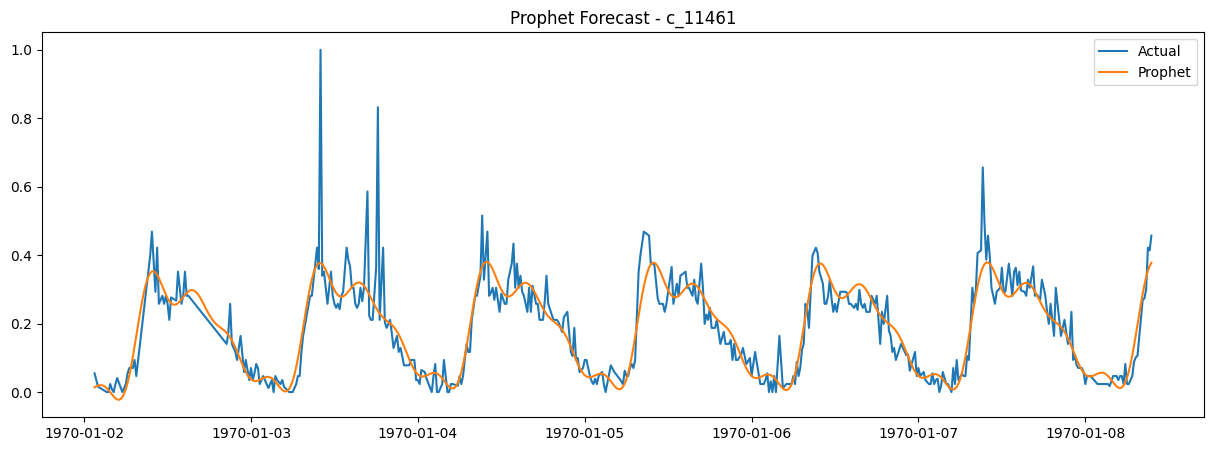

In [24]:
plt.figure(figsize=(15,5))

plt.plot(
    sample_df["time_stamp"],
    sample_df["cpu_scaled"],
    label="Actual"
)

plt.plot(
    sample_df["time_stamp"],
    sample_df["prophet_pred"],
    label="Prophet"
)

plt.title(
    f"Prophet Forecast - {sample_cid}"
)

plt.legend()

plt.show()

In [25]:
train_container = global_train[
    global_train["container_id"] == target_cid
].sort_values("time_stamp")

val_container = global_val[
    global_val["container_id"] == target_cid
].sort_values("time_stamp")

In [26]:
prophet_train = pd.DataFrame({
    "ds": train_container["time_stamp"],
    "y": train_container["cpu_scaled"]
})

prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=False
)

prophet_model.fit(prophet_train)

11:41:02 - cmdstanpy - INFO - Chain [1] start processing
11:41:02 - cmdstanpy - INFO - Chain [1] done processing


In [27]:
future_df = pd.DataFrame({
    "ds": val_container["time_stamp"].values[:192]
})

forecast = prophet_model.predict(
    future_df
)

In [28]:
val_container["prophet_pred"] = (
    forecast["yhat"].values
)

In [29]:
val_container.head()

,container_id,time_stamp,cpu_util_percent,cpu_usage,cpu,cpu_scaled,cpu_mean,cpu_std,cpu_max,cpu_min,hour,prophet_pred
2923,c_11461,1970-01-08 09:45:00,22.0,22.0,22.0,0.421875,0.181902,0.135836,1.0,0.0,9,0.382588
2924,c_11461,1970-01-08 10:00:00,23.0,23.0,23.0,0.445312,0.181902,0.135836,1.0,0.0,10,0.382810
2925,c_11461,1970-01-08 10:15:00,NaN,20.5,20.5,0.386719,0.181902,0.135836,1.0,0.0,10,0.379024
2926,c_11461,1970-01-08 10:30:00,18.0,18.0,18.0,0.328125,0.181902,0.135836,1.0,0.0,10,0.371844
2927,c_11461,1970-01-08 10:45:00,19.0,19.0,19.0,0.351562,0.181902,0.135836,1.0,0.0,10,0.362015


In [30]:
train_forecast = prophet_model.predict(
    prophet_train[["ds"]]
)

train_container["prophet_pred"] = (
    train_forecast["yhat"].values
)

train_container["residual"] = (
    train_container["cpu_scaled"]
    - train_container["prophet_pred"]
)

train_container["residual_scaled"] = (
    train_container["residual"] - res_mean
) / res_std

In [31]:
residual_input = (
    train_container["residual_scaled"]
    .values[-288:]
)

In [32]:
X_input = np.column_stack([
    residual_input
])

X_input = X_input.reshape(
    1,
    288,
    1
)

In [33]:
day1_residual_scaled = global_model.predict(
    X_input
)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 971ms/step


In [34]:
day1_residual = (
    day1_residual_scaled * res_std
) + res_mean
day1_residual.size

96

In [35]:
day1_prophet = (
    forecast["yhat"]
    .values[:96]
)
day1_prophet.size

96

In [36]:
day1_final_scaled = (
    day1_prophet + day1_residual
)

In [37]:
day2_input_residuals = np.concatenate([
    residual_input[96:],   # keep latest 192
    day1_residual_scaled                 # append predicted day1
])

X_day2 = day2_input_residuals.reshape(
    1,
    288,
    1
)

In [38]:
day2_residual_scaled = global_model.predict(
    X_day2
)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


In [39]:
day2_residual = (
    day2_residual_scaled * res_std
) + res_mean
day2_residual.size

96

In [40]:
day2_prophet = (
    forecast["yhat"]
    .values[96:192]
)
day2_prophet.size

57

In [41]:
available_len = len(day2_prophet)

day2_final_scaled = (
    day2_prophet
    + day2_residual[:available_len]
)
day2_final_scaled.size

57

In [42]:
actual_day1_scaled = (
    val_container["cpu_scaled"]
    .values[:96]
)

In [43]:
actual_day2_scaled = (
    val_container["cpu_scaled"]
     .values[96:96 + available_len]
)

In [44]:
scaler = scalers[target_cid]

# DAY 1
day1_final_real = scaler.inverse_transform(
    day1_final_scaled.reshape(-1,1)
)

actual_day1_real = scaler.inverse_transform(
    actual_day1_scaled.reshape(-1,1)
)

prophet_day1_real = scaler.inverse_transform(
    day1_prophet.reshape(-1,1)
)

# DAY 2
day2_final_real = scaler.inverse_transform(
    day2_final_scaled.reshape(-1,1)
)

actual_day2_real = scaler.inverse_transform(
    actual_day2_scaled.reshape(-1,1)
)

prophet_day2_real = scaler.inverse_transform(
    day2_prophet.reshape(-1,1)
)


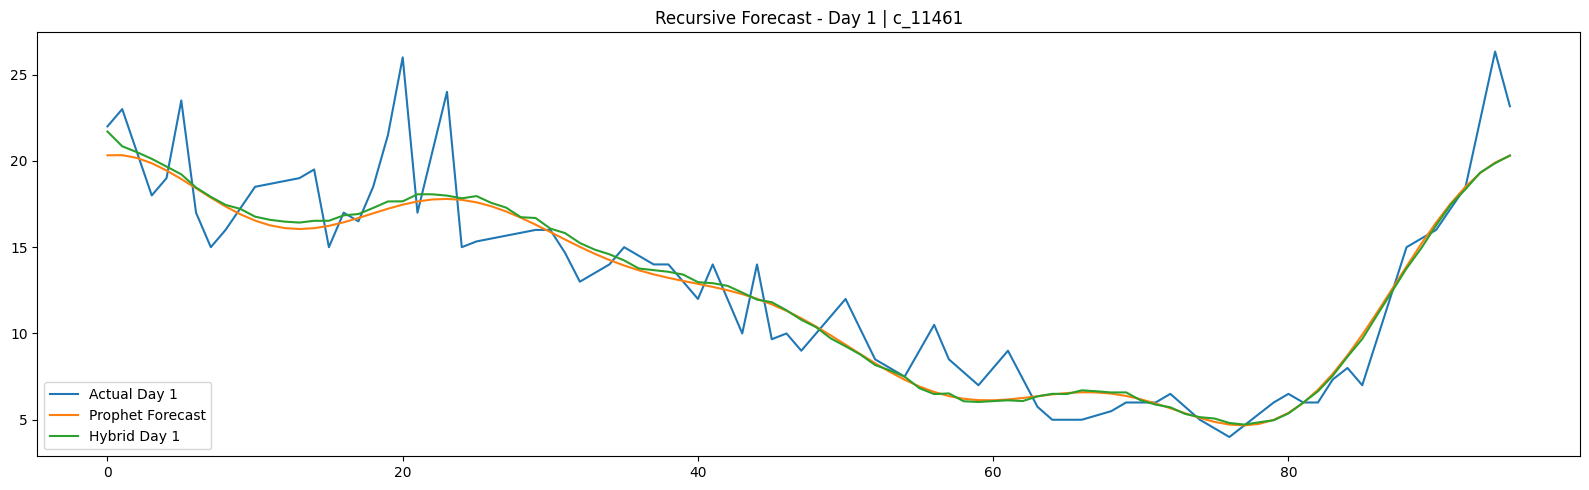

In [45]:
plt.figure(figsize=(16,5))

plt.plot(
    actual_day1_real,
    label="Actual Day 1"
)
plt.plot(
    prophet_day1_real,
    label="Prophet Forecast"
)
plt.plot(
    day1_final_real,
    label="Hybrid Day 1"
)
plt.title(
    f"Recursive Forecast - Day 1 | {target_cid}"
)
plt.legend()
plt.tight_layout()
plt.show()

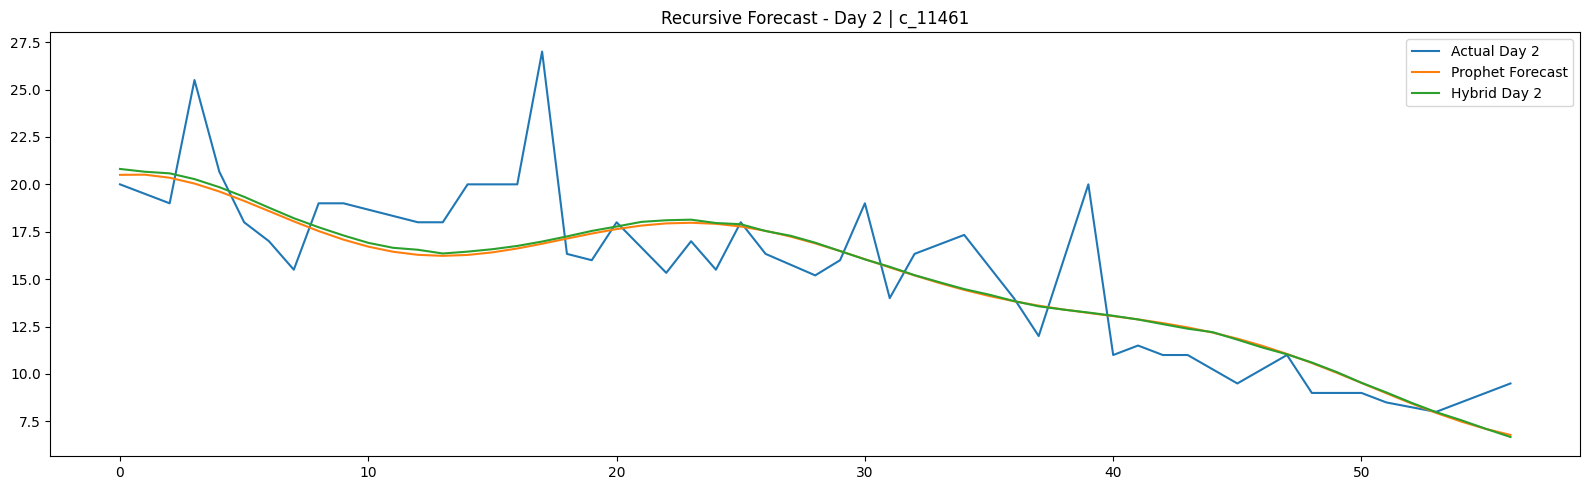

In [46]:
plt.figure(figsize=(16,5))

plt.plot(
    actual_day2_real,
    label="Actual Day 2"
)
plt.plot(
    prophet_day2_real,
    label="Prophet Forecast"
)
plt.plot(
    day2_final_real,
    label="Hybrid Day 2"
)
plt.title(
    f"Recursive Forecast - Day 2 | {target_cid}"
)
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
day1_mae = mean_absolute_error(
    actual_day1_real,
    day1_final_real
)
day1_rmse = np.sqrt(
    mean_squared_error(
        actual_day1_real,
        day1_final_real
    )
)
# DAY 2
day2_mae = mean_absolute_error(
    actual_day2_real,
    day2_final_real
)
day2_rmse = np.sqrt(
    mean_squared_error(
        actual_day2_real,
        day2_final_real
    )
)

print(f"\nDay 1 MAE  : {day1_mae:.4f}")
print(f"Day 1 RMSE : {day1_rmse:.4f}")
print(f"\nDay 2 MAE  : {day2_mae:.4f}")
print(f"Day 2 RMSE : {day2_rmse:.4f}")


Day 1 MAE  : 1.4712
Day 1 RMSE : 2.0333

Day 2 MAE  : 1.8476
Day 2 RMSE : 2.4506


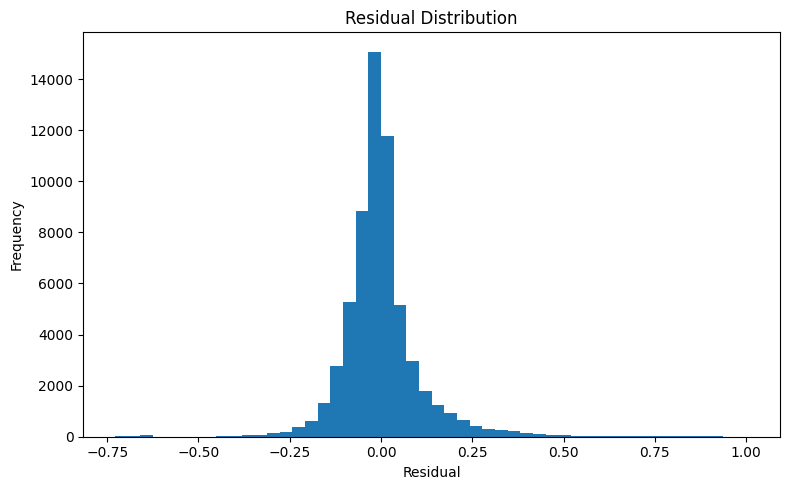

In [48]:
plt.figure(figsize=(8,5))

plt.hist(
    train_residual_df["residual"],
    bins=50
)

plt.title("Residual Distribution")

plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

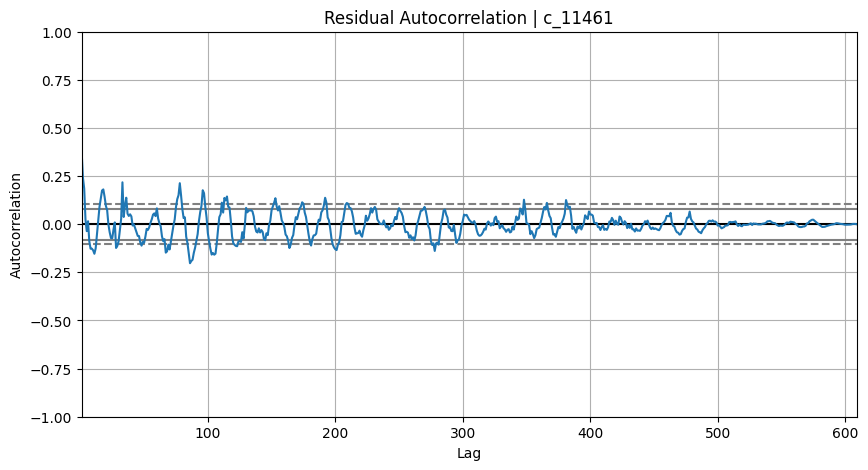

In [49]:
from pandas.plotting import autocorrelation_plot

plt.figure(figsize=(10,5))

autocorrelation_plot(
    sample_df["residual"]
)

plt.title(
    f"Residual Autocorrelation | {sample_cid}"
)

plt.show()

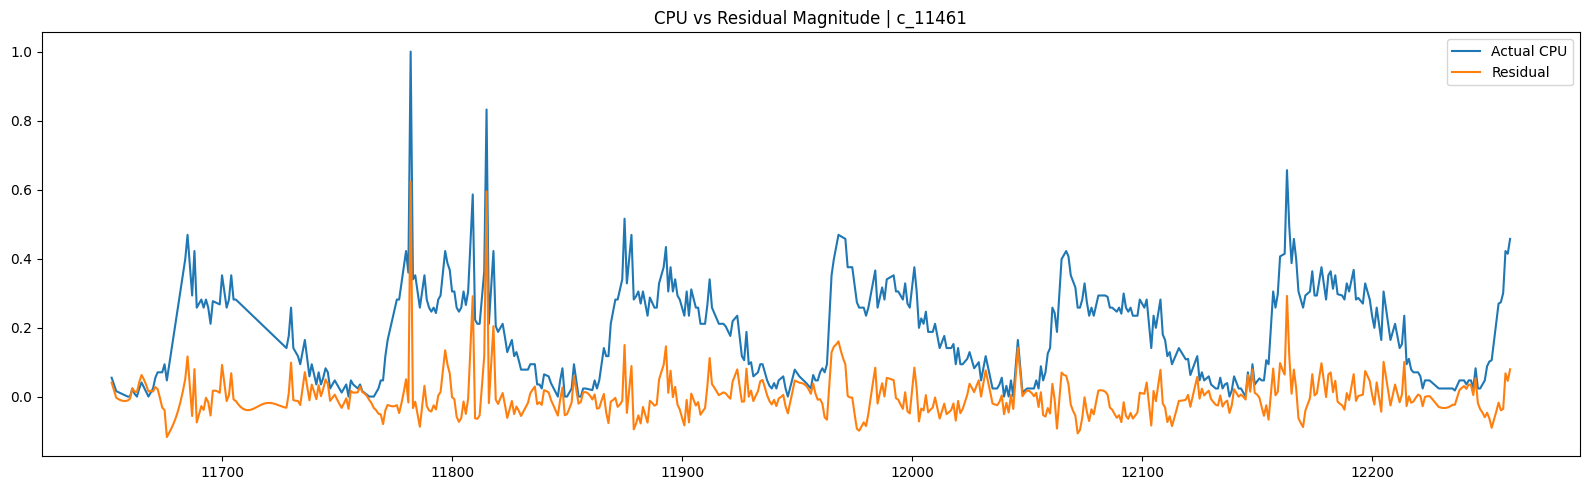

In [50]:
plt.figure(figsize=(16,5))

plt.plot(
    sample_df["cpu_scaled"],
    label="Actual CPU"
)

plt.plot(
    sample_df["residual"],
    label="Residual"
)

plt.legend()

plt.title(
    f"CPU vs Residual Magnitude | {sample_cid}"
)

plt.tight_layout()

plt.show()

In [51]:
global_model.save(
    "../models/hybrid_gru.keras"
)

In [52]:
with open(
    "../models/residual_stats.pkl",
    "wb"
) as f:
    pickle.dump(
        {
            "res_mean": res_mean,
            "res_std": res_std
        },
        f
    )